## Benchmarking Model for Flow Predictions in Sound Uroflowmeters

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
import pickle
from abc import ABC, abstractmethod
import random
import librosa

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

EPS = 1e-8

# CONSTANTS
data_pth = "../data/Data_Flow_JBHI_2"
SEED = 0
BATCH_SIZE = 2

# DEVICE CODES
UM_DEVICE_CODE = "um"
OPPO_DEVICE_CODE = "oppo"
PHONE_DEVICE_CODE = "phone"
NO_DEVICES = 3

# UMINZE SAMPLING RATE
MINZE_RATE = 100e-3
NO_FILES_PER_PATH = 4

## Abstraction class for DataLoadding

In [2]:
class Dataset(ABC):

    @abstractmethod
    def __len__(self):
        raise NotImplementedError(f"Subclasses must implement this method")
    
    @abstractmethod
    def __getitem__(self):
        raise NotImplementedError(f"Subclasses must implement this method")
    

def test_dataset():
    print(f"Testing Dataset class")
    
    try:
        dataset = Dataset()
        assert False, f"Must raise error, cannot create from an abstract class"
    except:
        pass

    print(f"Test passed")

if __name__== "__main__":
    test_dataset()

Testing Dataset class
Test passed


In [3]:
class UroflowmetryDataset(Dataset):

    def __init__(self, rootDir, device_code):
        
        assert device_code in range(NO_DEVICES), f"Device code not supported"
        self.device_code = device_code

        self.wav_files = []
        self.minze_readings = []
        self.device_codes = {0: UM_DEVICE_CODE, 1: OPPO_DEVICE_CODE, 2: PHONE_DEVICE_CODE}

        for patient_id in os.listdir(rootDir):
            if patient_id.startswith('.'):  # skip .DS_Store and hidden files
                continue
            patient_pth = os.path.join(rootDir, patient_id)
            files = [f for f in os.listdir(patient_pth) if not f.startswith('.')]
            assert len(files) == NO_FILES_PER_PATH, f"Mising data files for path {patient_pth}"
            
            temp = {}
            for device in [f for f in os.listdir(patient_pth) if not f.startswith('.')]:
                device_dir = os.path.join(patient_pth, device)

                if device_dir.endswith(".csv"):
                    self.minze_readings.append(device_dir)
                else:
                    assert device_dir.endswith(".wav"), f"Unsupported file extension {device_dir} detected"
                    if self.device_codes[0] in device_dir:
                        temp[self.device_codes[0]] = device_dir
                        
                    elif self.device_codes[1] in device_dir:
                        temp[self.device_codes[1]] = device_dir

                    elif self.device_codes[2] in device_dir:
                        temp[self.device_codes[2]] = device_dir
                    
            self.wav_files.append(temp)

        visible_dirs = [f for f in os.listdir(rootDir) if not f.startswith('.')]
        assert len(self.wav_files) == len(self.minze_readings), f"sound wav files and mnize readings count doesnot match"
        assert len(self.wav_files) == len(visible_dirs), f"Data is loaded incorrectly, it does not match with the raw records"


    def __len__(self):
        return len(self.minze_readings)
            
    def __getitem__(self, index):
        ##  TODO: allow all negative
        assert index in range(len(self)) or index == -1, f"Index out of bound, upper bound {len(self)}" 
        wav_file = self.wav_files[index][self.device_codes[self.device_code]]

        assert self.device_codes[self.device_code] in wav_file, f"{wav_file} not of type {self.device_codes[self.device_code]}"
        device_rate, sound_file = wavfile.read(wav_file)

        device_rate_ps = int(MINZE_RATE * device_rate)
        assert device_rate_ps == device_rate / 10, f"Error in device rate per second computation"

        MINZE_FLOW_RATE_INDEX = 0

        minze_device_reading = pd.read_csv(self.minze_readings[index]).to_numpy()[:, MINZE_FLOW_RATE_INDEX].astype(np.float32)
        no_readings_recorded = minze_device_reading.shape[0]
            
        device_sound_sampled_ps = np.array([sound_file[i * device_rate_ps: (i + 1) * device_rate_ps] for i in range(no_readings_recorded)])
        device_sound_sampled_ps = device_sound_sampled_ps.astype(np.float32)
        
        assert device_sound_sampled_ps.shape[0] == no_readings_recorded, f"Sound file not synchronized correctly"
        assert device_sound_sampled_ps.shape[0] == minze_device_reading.shape[0], f"Dims {device_sound_sampled_ps.shape}, {minze_device_reading.shape}"

        return device_sound_sampled_ps, minze_device_reading, device_rate


def test_uroflowDataset():
    print(f"Testing UroflowDataset")
    CODE = 2
    
    dataset = UroflowmetryDataset(data_pth, device_code=CODE)
    
    assert dataset.device_code == CODE
    assert dataset.device_codes[0] == "um", f"Device codes doesnot match"
    assert len(dataset) == len([f for f in os.listdir(data_pth) if not f.startswith('.')]), f"Data loaded incorrectly, missing records detected"
    
    x, y, _ = dataset[0]
    assert x.shape[0] == y.shape[0], f"Should have compatible batch dimensions"
    
    print(f"Test passed")
        

if __name__=='__main__':
    test_uroflowDataset()

Testing UroflowDataset
Test passed


## Uroflowmetry Dataset

In [4]:
''' class UroflowmetryDataset(Dataset):

    def __init__(self, rootDir, device_code):
        
        assert device_code in range(NO_DEVICES), f"Device code not supported"
        self.device_code = device_code

        self.wav_files = []
        self.minze_readings = []
        self.device_codes = {0: UM_DEVICE_CODE, 1: OPPO_DEVICE_CODE, 2: PHONE_DEVICE_CODE}

        for patient_id in os.listdir(rootDir):
            patient_pth = os.path.join(rootDir, patient_id)
            assert len(os.listdir(patient_pth)) == NO_FILES_PER_PATH, f"Mising data files for path {patient_pth}"


            
            temp = {}
            for device in os.listdir(patient_pth):
                device_dir = os.path.join(patient_pth, device)

                if device_dir.endswith(".csv"):
                    self.minze_readings.append(device_dir)
                else:
                    assert device_dir.endswith(".wav"), f"Unsupported file extension {device_dir} detected"
                    if self.device_codes[0] in device_dir:
                        temp[self.device_codes[0]] = device_dir
                        
                    elif self.device_codes[1] in device_dir:
                        temp[self.device_codes[1]] = device_dir

                    elif self.device_codes[2] in device_dir:
                        temp[self.device_codes[2]] = device_dir
                    
            self.wav_files.append(temp)

        
        assert len(self.wav_files) == len(self.minze_readings), f"sound wav files and mnize readings count doesnot match"
        assert len(self.wav_files) == len(os.listdir(rootDir)), f"Data is loaded incorrectly, it does not match with the raw records"

                

    def __len__(self):
        return len(self.minze_readings)
            
    
            
    def __getitem__(self, index):
        ##  TODO: allow all negative
        assert index in range(len(self)) or index == -1, f"Index out of bound, upper bound {len(self)}" 
        wav_file = self.wav_files[index][self.device_codes[self.device_code]]

        assert self.device_codes[self.device_code] in wav_file, f"{wav_file} not of type {self.device_codes[self.device_code]}"
        device_rate, sound_file = wavfile.read(wav_file)

        device_rate_ps = int(MINZE_RATE * device_rate)
        assert device_rate_ps == device_rate / 10, f"Error in device rate per second computation"

        MINZE_FLOW_RATE_INDEX = 0

        minze_device_reading = pd.read_csv(self.minze_readings[index]).to_numpy()[:, MINZE_FLOW_RATE_INDEX].astype(np.float32)
        no_readings_recorded = minze_device_reading.shape[0]
            
        device_sound_sampled_ps = np.array([sound_file[i * device_rate_ps: (i + 1) * device_rate_ps] for i in range(no_readings_recorded)])
        device_sound_sampled_ps = device_sound_sampled_ps.astype(np.float32)
        
        assert device_sound_sampled_ps.shape[0] == no_readings_recorded, f"Sound file not synchronized correctly"
        assert device_sound_sampled_ps.shape[0] == minze_device_reading.shape[0], f"Dims {device_sound_sampled_ps.shape}, {minze_device_reading.shape}"

        return device_sound_sampled_ps, minze_device_reading, device_rate
                


def test_uroflowDataset():
    print(f"Testing UroflowDataset")
    CODE = 2
    
    dataset = UroflowmetryDataset(data_pth, device_code=CODE)
    
    assert dataset.device_code == CODE
    assert dataset.device_codes[0] == "um", f"Device codes doesnot match"
    assert len(dataset) == len(os.listdir(data_pth)), f"Data loaded incorrectly, missing records detected"
    
    x, y,_ = dataset[0]
    assert x.shape[0] == y.shape[0], f"Should have compatible batch dimensions"
    
    print(f"Test passed")
        

if __name__=='__main__':
    test_uroflowDataset()


SyntaxError: incomplete input (1214216586.py, line 1)

## Abstract Transform 

In [5]:
class Transform(ABC):

    @abstractmethod
    def forward(self, x):
        raise NotImplementedError("Subclasses must implement this method")

    def __call__(self, x):
        return self.forward(x)

    def fit_transform(self, x):
        return self.forward(x)

def test_Transform():
    print("Testing Transform")

    try:
        transform = Transform()
        assert False, f"Must have raised an error, cannot create an abstract class"
    except:
        pass

    print("Test passed")

if __name__=="__main__":
    test_Transform()

Testing Transform
Test passed


## Linear Forier Transformation

In [6]:
class LFT(Transform):

    def __init__(self, num_bins):
        self.num_bins = num_bins
        
    def forward(self, x, axis= 1):
        x_fft = np.fft.rfft(x, axis=axis)
        x_mag = np.abs(x_fft)

        num_freqs = x_mag.shape[axis]
        bin_edges = np.linspace(0, num_freqs, self.num_bins + 1, dtype="int")

        x_binned = np.zeros((x.shape[0], self.num_bins), dtype=np.float32)

        for i in range(self.num_bins):
            start, end = bin_edges[i], bin_edges[i+1]
            binned_slice = x_mag[:, start:end]
            x_binned[:, i] = binned_slice.sum(axis= 1) if not binned_slice.size == 0 else 0

        assert x_binned.shape == (x.shape[0], self.num_bins), f"Inconsistent shape after linear bin transformation"
        return x_binned


def test_LFT():
    print(f"Testing  Linear Fourier Transform")

    dataset = UroflowmetryDataset(data_pth, 0)

    x, y,_ = dataset[4]
    
    NO_BINS = 20
    
    lft = LFT(NO_BINS)
    x_binned = lft.fit_transform(x)
    assert x_binned.shape[-1] == 20, f"Inconsistent output dimensions"

    # print(x_binned.shape)


    print("Test passed")


if __name__ == "__main__":
    test_LFT()

Testing  Linear Fourier Transform
Test passed


## Mel-spectrogram Transformation

In [7]:
class MelSpectrogram(Transform):

    def __init__(self, n_fft=1024, n_mels=20, power= 2.0, enable_2d= False, d_scale_factor = 32):
        self.n_fft = n_fft
        self.power = power
        self.n_mels = n_mels
        self.enable_2d  = enable_2d
        self.d_scale_factor = d_scale_factor
        

    def forward(self, x, sr):

        features = []
        printed = False
        
        for window in x:
            mel_spec = librosa.feature.melspectrogram(y=window, sr=sr, n_fft=self.n_fft, hop_length= self.n_fft // self.d_scale_factor, \
                                                     n_mels= self.n_mels, power= self.power)
            log_mel = librosa.power_to_db(mel_spec, ref=np.max)
            mel_features = log_mel if self.enable_2d else log_mel.sum(axis=1)


            features.append(mel_features)
        return np.stack(features)

    def fit_transform(self, x, sr):
        return self.forward(x, sr)
        
        
def test_melSpectrogram():
    print(f'Testing Melspectrogram Transformation')
    

    dataset = UroflowmetryDataset(data_pth, device_code=1)
    x, y, _ = dataset[2]

    MAX_DIM = 20
    ENABLE_2D = True
    NO_SAMPLES= len([f for f in os.listdir(data_pth) if not f.startswith('.')])
    noted_dim = 0
    
    for i in range(NO_SAMPLES):
        x, y, sr = dataset[i]
        mel_spec= MelSpectrogram(enable_2d= ENABLE_2D)
        x_mel = mel_spec.fit_transform(x, sr=sr)

        if i == 0:
            noted_dim = x_mel.shape[-1]
            print(x_mel.shape, y.shape)
        else:
            assert x_mel.shape[-1] == noted_dim, f"Inconsistent dims {i}: {x_mel.shape} with {noted_dim} during 2D Mel-spectrogram transformation"


    if not ENABLE_2D:
        assert x_mel.shape == (x.shape[0], MAX_DIM), f"Inconsistent shape during mel-spectrogram computation"

    print(f'Test passed')

if __name__ == "__main__":
    test_melSpectrogram()
    

Testing Melspectrogram Transformation
(300, 20, 138) (300,)
Test passed


## Abstract DataLaoder 

In [8]:
class DataLoader:
    
    def __init__(self, batch_size, seed, shuffle= False):
        self.batch_size = batch_size
        self.seed = seed
        self.shuffle = shuffle
        

    def forward(self, dataset: Dataset):
        raise NotImplementedError(f"Subclasses must implement the foward method")

    def __call__(self, dataset: Dataset):
        return self.forward(dataset)


def test_dataloader():
    print(f"Testing DataLoader Abstract class")

    
    dataloader = DataLoader(BATCH_SIZE, SEED)
    assert dataloader.batch_size == BATCH_SIZE, f"Incorrect batch intialization"
    assert dataloader.seed == SEED, f"Incorrect seed initialization"

    print(f"Test passed")

if __name__ == "__main__":
    test_dataloader()

Testing DataLoader Abstract class
Test passed


## Uroflowmetry DataLoader

In [ ]:
class UroflowmetryDataLoader(DataLoader):

    def __init__(self, batch_size, seed, transform, shuffle= False, out_dim= 20, use_ltf = True, enable_2d= False):
        super().__init__(batch_size, seed, shuffle)
        self.out_dim = out_dim
        self.transform = transform
        self.use_ltf = use_ltf
        self.enable_2d = enable_2d

    def forward(self, dataset):
        size = len(dataset)

        indices = list(range(size))
        
        if self.shuffle:
            random.shuffle(indices)
        
        for i in range(0, size, self.batch_size):
            sampled_indices = indices[i : i + self.batch_size]
            temp = []
            for index in sampled_indices:
                x, y, sr = dataset[index]
                if self.use_ltf:
                    x_transformed = self.transform.fit_transform(x)
                else:
                    x_transformed = self.transform.fit_transform(x, sr)
                    
                temp.append((x_transformed, y))
        
            yield stacked(temp, self.out_dim)


    def extract_cluster_features(self, dataset):   
        """Precomputes one feature vector per patient for clustering"""
        patient_features = []

        for index in range(len(dataset)):
            x, y, sr = dataset[index]
            if self.use_ltf:
                x_transformed = self.transform.fit_transform(x)
            else:
                x_transformed = self.transform.fit_transform(x, sr)

            #Aggregate windows 
            mean_vec = x_transformed.mean(axis=0)
            std_vec = x_transformed.std(axis=0)
            patient_vec = np.concatenate([mean_vec, std_vec], axis=0)

            patient_features.append(patient_vec)


        return np.stack(patient_features)    



def stacked(unstacked_batch, out_dim=20):
    features= []
    targets = []
    shape_checkpoint = 0
    no_samples = len(unstacked_batch)
    
    
    for i in range(no_samples):
        wav_file = unstacked_batch[i][0]
        minze_reading = unstacked_batch[i][-1]

        shape_checkpoint += wav_file.shape[0]

        features.append(wav_file)
        targets.append(minze_reading)

    concat_features = np.concatenate(features, axis=0)
    concat_targets = np.concatenate(targets, axis= 0)

    

    assert concat_features.shape[1] == out_dim, f"Incosistent shape of sound readings during merging"
    assert concat_targets.shape == (shape_checkpoint, ), f"Inconsistent shape of minze readings during merging"

    return concat_features, concat_targets


def test_custom_dataloader():
    print(f"Testing Uroflowmetry Dataloader")

    BATCH_SIZE = 4
    OUT_DIM = NO_BINS = 20
    ENABLE_2D = True

    lft = LFT(num_bins=NO_BINS)
    mel_spectrogram = MelSpectrogram(n_mels= NO_BINS, enable_2d= ENABLE_2D)
    
    
    dataset = UroflowmetryDataset(data_pth, device_code=0)
    dataloader = UroflowmetryDataLoader(BATCH_SIZE, SEED, mel_spectrogram, shuffle=True, use_ltf=False)
    
    assert dataloader.shuffle == True, f"shuffle not initialized correctly"
    assert dataloader.seed == SEED
    assert dataloader.batch_size == BATCH_SIZE

    dataloader = dataloader(dataset)

    data_iter = iter(dataloader)
    x, y = next(data_iter)
    print(x.shape, y.shape)
    
    print(f"Test passed")

if __name__=="__main__":
    test_custom_dataloader()

Testing Uroflowmetry Dataloader
(960, 20, 601) (960,)
Test passed


## Flow curve visualization helper

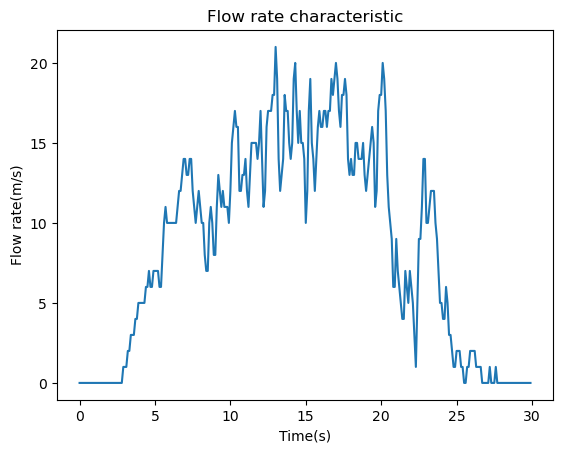

In [10]:
def visualize_flow_rate(flow, sampling_frq= 100e-3):
    time = np.array([i * sampling_frq for i  in range(len(flow))])
    plt.plot(time, flow)
    plt.xlabel(f'Time(s)')
    plt.ylabel(f'Flow rate(m/s)')
    plt.title('Flow rate characteristic')
    plt.show()

def test_visualization():
    
    dataset = UroflowmetryDataset(data_pth, device_code=1)
    x, y, _ = dataset[2]
    visualize_flow_rate(y)
    

if __name__== "__main__":
    test_visualization()

## Data Preprocessing

In [11]:
def load_dataset(rootDir, batch_size, device_code, transform, test_split= 0.2, use_ltf= False, seed=SEED, out_dim=20):
    
    dataset = UroflowmetryDataset(rootDir, device_code= device_code)
    dataloader = UroflowmetryDataLoader(batch_size, seed, transform, shuffle= True, use_ltf= use_ltf, out_dim=out_dim)(dataset)

    data_iter = iter(dataloader)
    x, y, = next(data_iter)

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= test_split, random_state= SEED)
    return x_train, x_test, y_train, y_test


def test_load_dataset():
    print("Testing load dataset function")

    NO_BINS = 20
    ENABLE_2D = True
    BATCH_SIZE = len(os.listdir(data_pth)) // 8
    
    lft= LFT(num_bins=NO_BINS)
    mel_spectrogram = MelSpectrogram(n_mels= NO_BINS, enable_2d= ENABLE_2D)


    x, _, y, _ = load_dataset(data_pth, BATCH_SIZE, device_code=0, transform=mel_spectrogram, use_ltf= False)
    assert x.shape[0] == y.shape[0], f"First dimensions must match"

    print(x.shape, y.shape)

    print("Test passed")

if __name__ == "__main__":
    test_load_dataset()

Testing load dataset function
(1392, 20, 601) (1392,)
Test passed


## Model Training

In [12]:

import warnings
warnings.filterwarnings('ignore')

def train_test():
    
    NO_BINS = 20
    ENABLE_2D = False
    BATCH_SIZE = len(os.listdir(data_pth))
    
    MODELS = {
        "rf": RandomForestRegressor(n_estimators=100, max_depth=20, min_samples_split=5, max_features="sqrt", criterion="squared_error"), 
        "svr": SVR(kernel="rbf", C=1, epsilon=0.1, gamma="auto"), 
        "xgboost":XGBRegressor(n_estimators=100, learning_rate=0.05, objective="reg:squarederror")
    }

    ltf= LFT(num_bins=NO_BINS)

    global_state = {}
    for code in range(3):
        x_train, x_test, y_train, y_test= load_dataset(data_pth, BATCH_SIZE, device_code= code, transform=ltf, use_ltf=True)
        
        temp = {}
        for model in MODELS.keys():
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('regressor', TransformedTargetRegressor(
                    regressor= MODELS[model],
                    transformer= StandardScaler()
                ))
            ])
            
            pipeline.fit(x_train, y_train)
            y_pred = pipeline.predict(x_test)
            
            r2 = r2_score(y_test, y_pred)
            mae = mean_absolute_error(y_pred, y_test)
            
            state_data = {'pred': y_pred, 'r2': r2, 'mae': mae, 'pipeline': pipeline}
            temp[model] = state_data 
        global_state[code] = temp

    return global_state

result_state = train_test()

## Utility State Management 

In [13]:
def save_state(state_dict, pth):
    
    with open(pth, "wb") as f:
        pickle.dump(state_dict, f)

def load_state(path):
    
    with open(path, "rb") as f:
        state_dict = pickle.load(f)
    return state_dict

def test_state_management():
    print(f"Testing state management functions")

    save_state(result_state, "state_dict.pkl")
    state_dict  = load_state("./state_dict.pkl")

    print(f"Test passed")

if __name__ == "__main__":
    test_state_management()

PATH = "state_dict.pkl"
save_state(result_state, PATH)

Testing state management functions
Test passed


## Result Extraction Helper

In [14]:
def extract_device_results(state_dict, device_code = 0):
    MODELS = ["rf", "svr", "xgboost"]
    metrics = ["r2", "mae"]
    
    r2_scores = []
    mae_scores = []
    
    for model in MODELS:
        r2_scores.append(state_dict[device_code][model][metrics[0]])
        mae_scores.append(state_dict[device_code][model][metrics[-1]])
    
    results_df = pd.DataFrame(data=np.array([r2_scores, mae_scores]), columns= MODELS, index=metrics)
    
    return results_df


def test_result_extraction():
    print("Testing Result Extraction")

    state_dict = load_state(os.path.join("./", PATH))
    device_0 = extract_device_results(state_dict)

    print("Test passed")

if __name__ == "__main__":
    test_result_extraction()

Testing Result Extraction
Test passed


## Summarized Results

In [15]:
DEVICE_CODES = {0: UM_DEVICE_CODE, 1: OPPO_DEVICE_CODE, 2: PHONE_DEVICE_CODE}
state_dict = load_state(os.path.join("./", PATH))

print(f"\nEXPERIMENTATION RESULTS PER DEVICE USED IN DATA COLLECTION\n")

for device in DEVICE_CODES.keys():
    device_df = extract_device_results(state_dict, device)

    print(f"Test Results for Device {device}: {DEVICE_CODES[device]}")
    print("-"*35)
    print(device_df)
    print("\n")  



EXPERIMENTATION RESULTS PER DEVICE USED IN DATA COLLECTION

Test Results for Device 0: um
-----------------------------------
           rf       svr   xgboost
r2   0.731805  0.686153  0.732635
mae  2.955854  3.185230  2.953351


Test Results for Device 1: oppo
-----------------------------------
           rf       svr   xgboost
r2   0.810239  0.799929  0.807429
mae  2.388245  2.444570  2.407366


Test Results for Device 2: phone
-----------------------------------
           rf       svr   xgboost
r2   0.802805  0.802077  0.802051
mae  2.500951  2.510121  2.492102




## CNN Batching Helper

In [16]:
class CNN_DataLoader(Transform):

    def __init__(self, no_batches):
        self.size = None
        self.no_batches = no_batches

    def forward(self, x, y):
        x = torch.Tensor(x) if not isinstance(x, torch.Tensor) else x
        y = torch.Tensor(y) if not isinstance(y, torch.Tensor) else y
        
        self.size = x.shape[0]

        for i in range(0, self.size, self.no_batches):
            yield x[i: i + self.no_batches], y[i : i + self.no_batches]

    def __call__(self, x, y):
        return self.forward(x, y)


def test_generate_cnn_batches():
    print(f"Testing CNN batch generation")

    ENABLE_2D = True
    NO_BINS = 20
    mel_spectrogram = MelSpectrogram(n_mels= NO_BINS, enable_2d= ENABLE_2D)
    BATCH_SIZE = 20
    
    x_train, x_test, y_train, y_test = load_dataset(data_pth, BATCH_SIZE, device_code=0, transform=mel_spectrogram, use_ltf=False)
    cnn_dataloader = CNN_DataLoader(10)

    for x, y in cnn_dataloader(x_train, y_train):
        print(x.shape, y.shape)
        break

    print(f"Test passed")

if __name__ == "__main__":
    test_generate_cnn_batches()

Testing CNN batch generation
torch.Size([10, 20, 601]) torch.Size([10])
Test passed


## CNN model Implementation

In [17]:
class UroflowCNN(nn.Module):
    def __init__(self, input_channels=20, input_length=601):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, input_length)
            out = self.features(dummy)
            feature_dim = out.shape[1]

        self.regressor = nn.Linear(feature_dim, 1)

    def forward(self, x):
        x = self.features(x)
        x = x.squeeze(-1)
        return self.regressor(x)

def test_uroflowCNN():
    print(f'Testing Uroflow CNN model')

    cnn_model = UroflowCNN()
    x = torch.randn(20, 20, 601)

    out = cnn_model.forward(x)
    assert out.shape == (x.shape[0], 1), f"Inconsistent output dimensions, during CNN computations"

    print(f'Test passed')

if __name__=="__main__":
    test_uroflowCNN()

Testing Uroflow CNN model
Test passed


## CNN training run Configurations

In [18]:
def train_one_epoch(model, x_train, y_train, batch_loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0

    for x, y in batch_loader(x_train, y_train):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        preds = model(x)
        loss = loss_fn(preds.flatten(), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
    return running_loss / batch_loader.size

@torch.no_grad()
def validate(model, x_val, y_val, batch_loader, loss_fn, device):
    model.eval()

    running_mse = 0.0
    total_samples = 0

    all_preds = []
    all_targets = []

    for x, y in batch_loader(x_val, y_val):
        x, y = x.to(device), y.to(device)

        preds = model(x).flatten()
        loss = loss_fn(preds, y)
        running_mse += loss.item() * x.size(0)
        total_samples += x.size(0)

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

    all_preds = torch.cat(all_preds)
    all_targets= torch.cat(all_targets)

    mse = running_mse / total_samples
    mae = torch.mean(torch.abs(all_preds - all_targets)).item()

    # R² computation
    ss_res = torch.sum((all_targets - all_preds)**2)
    ss_tot = torch.sum((all_targets - torch.mean(all_targets))**2)
    r2 = (1 - ss_res / ss_tot).item()
    
    return mse, mae, r2
    
    
def test_model_training():
    print(f'Testing Model Training')

    x_train = torch.randn(40, 20, 601)
    y_train = torch.randn(40)

    x_test = torch.randn(6, 20, 601)
    y_test = torch.randn(6)

    cnn_dataloader = CNN_DataLoader(no_batches= 10)
    
    model = UroflowCNN()
    loss_fn = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.1)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    loss = train_one_epoch(model, x_train, y_train, cnn_dataloader, optimizer, loss_fn, device)
    mse, mae, r2 = validate(model, x_test, y_test, cnn_dataloader, loss_fn , device)

    print(f'Test passed')

if __name__ == "__main__":
    test_model_training()

Testing Model Training
Test passed


## Channel Normalizations

In [19]:
def compute_channel_stats(x_train, y_train, cnn_dataloader, device):
    x_sum = x_sum_sq = x_count = 0
    y_sum = y_sum_sq = y_count = 0

    for x, y in cnn_dataloader(x_train, y_train):
        x = torch.Tensor(x).to(device)
        y = torch.Tensor(y).to(device)

        x_sum += x.sum(dim=(0, 2))
        x_sum_sq += (x **2).sum(dim=(0, 2))
        x_count += x.shape[0] * x.shape[2]

        y_sum += y.sum()
        y_sum_sq += (y ** 2).sum()
        y_count += y.numel()
    
    x_mean = x_sum / x_count
    x_std = torch.sqrt(x_sum_sq / x_count - x_mean **2)

    y_mean = y_sum / y_count
    y_std = torch.sqrt(y_sum_sq / y_count - y_mean **2)

    return (x_mean.view(1, -1, 1), x_std.view(1, -1, 1), y_mean, y_std)


def normalize_x(x, mean, std):
    if not isinstance(x, torch.Tensor):
        x = torch.Tensor(x)
    return (x - mean) / (std + EPS)

def normalize_y(y, mean, std):
    if not isinstance(y, torch.Tensor):
        y = torch.Tensor(y)
    return (y - mean) / (std + EPS)

def de_normalize_y(y_norm, mean, std):
    return y_norm * std + mean


def test_normalization():
    print(f'Testing normalization')

    x = torch.randn(20, 20, 601)
    y = torch.randn(20)

    data_loader = CNN_DataLoader(no_batches=10)
    x_mean, x_std, y_mean, y_std = compute_channel_stats(x, y, data_loader, device="cpu")

    x_norm = normalize_x(x, x_mean, x_std)
    y_norm = normalize_y(y, y_mean, y_std)

    y_orig = de_normalize_y(y_norm, y_mean, y_std)
    assert torch.allclose(y_orig, y, atol=EPS), f"Error during inverse computation"

    print(f'Test passed')

if __name__ == "__main__":
    test_normalization()

Testing normalization
Test passed


## CNN model Training

In [ ]:
def train_cnn_model(epochs= 20, batch_size=32, lr=1e-3):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    NO_BINS = 40
    BATCH_SIZE = len(os.listdir(data_pth)) 
    ENABLE_2D = True
    mel_spectrogram = MelSpectrogram(n_mels= NO_BINS, enable_2d=ENABLE_2D)
    CNN_BATCH = 8
    
    x_train, x_test, y_train, y_test = load_dataset(data_pth, BATCH_SIZE, device_code=1, transform=mel_spectrogram, use_ltf= False, out_dim=NO_BINS)

    cnn_dataloader = CNN_DataLoader(no_batches=CNN_BATCH)
    x_mean, x_std, y_mean, y_std = compute_channel_stats(x_train, y_train, cnn_dataloader, device)

    x_train, x_test = normalize_x(x_train, x_mean, x_std), normalize_x(x_test, x_mean, x_std)
    y_train, y_test = normalize_y(y_train, y_mean, y_std), normalize_y(y_test, y_mean, y_std)

    model= UroflowCNN(x_train.shape[-2], x_train.shape[-1]).to(device)
    optimizer = Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, x_train, y_train, cnn_dataloader, optimizer, loss_fn, device)
        mse, mae, r2 = validate(model, x_test, y_test, cnn_dataloader, loss_fn, device)

        print(f"Epoch [{epoch}/{epochs}] | Train MSE: {train_loss:.4f} | Val MSE: {mse:.4f} | Val MAE: {mae:.4f} | Val r2: {r2:.4f}")
    return model  

train_cnn_model()

Epoch [1/20] | Train MSE: 0.3560 | Val MSE: 0.2888 | Val MAE: 0.4060 | Val r2: 0.7133
Epoch [2/20] | Train MSE: 0.3065 | Val MSE: 0.2776 | Val MAE: 0.3995 | Val r2: 0.7244
Epoch [3/20] | Train MSE: 0.2894 | Val MSE: 0.2698 | Val MAE: 0.3913 | Val r2: 0.7322
Epoch [4/20] | Train MSE: 0.2765 | Val MSE: 0.2674 | Val MAE: 0.3887 | Val r2: 0.7346
Epoch [5/20] | Train MSE: 0.2662 | Val MSE: 0.2555 | Val MAE: 0.3778 | Val r2: 0.7464
Epoch [6/20] | Train MSE: 0.2568 | Val MSE: 0.2503 | Val MAE: 0.3723 | Val r2: 0.7515
Epoch [7/20] | Train MSE: 0.2480 | Val MSE: 0.2497 | Val MAE: 0.3714 | Val r2: 0.7521
Epoch [8/20] | Train MSE: 0.2401 | Val MSE: 0.2513 | Val MAE: 0.3727 | Val r2: 0.7505
Epoch [9/20] | Train MSE: 0.2329 | Val MSE: 0.2482 | Val MAE: 0.3707 | Val r2: 0.7536
Epoch [10/20] | Train MSE: 0.2257 | Val MSE: 0.2441 | Val MAE: 0.3685 | Val r2: 0.7577
Epoch [11/20] | Train MSE: 0.2183 | Val MSE: 0.2443 | Val MAE: 0.3695 | Val r2: 0.7575


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

def run_kmeans_clustering(data_pth, device_code, n_clusters=3, save_pth="../results/"):

    # Setup
    NO_BINS = 20
    mel = MelSpectrogram(n_mels=NO_BINS, enable_2d=False)
    dataset = UroflowmetryDataset(data_pth, device_code=device_code)
    loader  = UroflowmetryDataLoader(BATCH_SIZE, SEED, mel, use_ltf=False)

    # Step 1: Extract one feature vector per patient
    print(f"Extracting cluster features for {len(dataset)} patients...")
    X_patients = loader.extract_cluster_features(dataset)  # (N, 40)
    print(f"Feature matrix shape: {X_patients.shape}")

    # Step 2: Scale
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_patients)

    # Step 3: K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    print(f"\nCluster assignments:")
    for cluster_id in range(n_clusters):
        members = np.where(labels == cluster_id)[0]
        print(f"  Cluster {cluster_id}: {len(members)} patients → indices {members.tolist()}")

    # Step 4: Save
    os.makedirs(save_pth, exist_ok=True)
    results = {
        "labels":       labels,
        "feature_matrix": X_patients,
        "kmeans_model": kmeans,
        "scaler":       scaler,
        "device_code":  device_code,
        "n_clusters":   n_clusters
    }
    out_file = os.path.join(save_pth, f"kmeans_device{device_code}.pkl")
    with open(out_file, "wb") as f:
        pickle.dump(results, f)

    print(f"\nSaved to {out_file}")
    return results


if __name__ == "__main__":
    results = run_kmeans_clustering(data_pth, device_code=0, n_clusters=3)

Extracting cluster features for 47 patients...


NameError: name 'patients_features' is not defined